In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

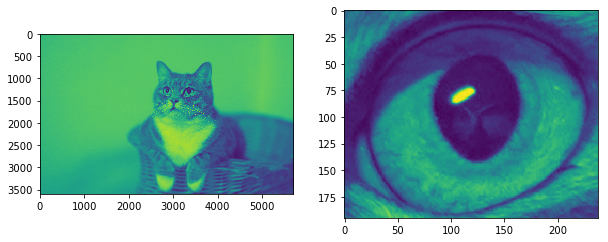

In [5]:
cat_full = cv2.imread(r"C:\Users\monukoru\Downloads\trial\cat.jpg",0)
cat_eye = cv2.imread(r"C:\Users\monukoru\Downloads\trial\cat_eye.jpg",0)

cat_color = cv2.imread(r"C:\Users\monukoru\Downloads\trial\cat.jpg")
cat_color = cv2.cvtColor(cat_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))

plt.subplot(221)
plt.imshow(cat_full)

plt.subplot(222)
plt.imshow(cat_eye)

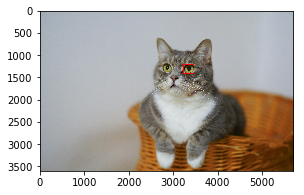

completion 1.0267462730407715 seconds


In [8]:
scale = 0.5
start = time.time()
# Grayscale and resize
cat_full_small = cv2.resize(cat_full, (0, 0), fx=scale, fy=scale,interpolation= cv2.INTER_AREA)
cat_eye_small = cv2.resize(cat_eye, (0, 0), fx=scale, fy=scale,interpolation= cv2.INTER_AREA)

# Match template

eye = cv2.matchTemplate(cat_full_small, cat_eye_small, cv2.TM_CCOEFF)
                                                                                                        # here we are applying operation on resized image so that algo becomes 
                                                                                                        # faster by scaling it to 0.5 then divided it's box co-ordinate by 0.5
                                                                                                        # so to ensure the scaling the of co-ordinate too. then we applied 
                                                                                                        # cv2.rectangle on a copy which is not resized. And other small optimizing
                                                                                                        # like variable and nesting helped a lot 

# Locate match
_, _, _, max_loc = cv2.minMaxLoc(eye)
top_left = (int(max_loc[0]/scale), int(max_loc[1]/scale))
bottom_right = (int((max_loc[0] + cat_eye_small.shape[1])/scale), int((max_loc[1] + cat_eye_small.shape[0])/scale))

# Draw on original image
cv2.rectangle(cat_color, top_left, bottom_right, (255,0,0), 9)

# Show
plt.figure(figsize=(10,10))
plt.subplot(122), plt.imshow(cat_color)
plt.show()
print("completion", time.time() - start, "seconds")